# Detección de Anomalías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from tensorflow import keras

# 1. Contexto


En esta sección se presenta un conjunto de técnicas de Inteligencia Artificial Explicable (XAI) aplicadas comúnmente a la detección de anomalías en datos de series temporales, con especial énfasis en su relevancia para sistemas aeronáuticos y aeroespaciales críticos para la seguridad. El enfoque se centra en los mecanismos de explicación que ofrecen los diferentes enfoques de XAI y en el tipo de información analítica que proporcionan al interpretar comportamientos anómalos. Cada técnica se discute desde una perspectiva conceptual y se ilustra dentro de un contexto de aplicación común para facilitar su comparación.

Para fundamentar la discusión, las técnicas se ilustran utilizando un escenario representativo de detección de anomalías basado en el conjunto de datos **CMAPSS**, desarrollado por el Centro de Excelencia en Pronósticos de la NASA. CMAPSS simula la degradación de motores turbofán operando bajo diversas condiciones y proporciona datos de series temporales multivariantes recopilados de múltiples sensores a lo largo de trayectorias completas de funcionamiento hasta el fallo (*run-to-failure*). Debido a su realismo y estructura controlada, este conjunto de datos se ha convertido en un estándar de referencia para estudios de mantenimiento predictivo, estimación de la vida útil restante (RUL) y detección de anomalías en sistemas aeroespaciales.

Como sistema de decisión subyacente, se considera un modelo de detección de anomalías basado en una red neuronal **Long Short-Term Memory (LSTM)**. Las arquitecturas LSTM son especialmente adecuadas para modelar dependencias temporales y tendencias de degradación en datos secuenciales de sensores, y se utilizan ampliamente en aplicaciones de monitorización de la salud de los motores.

En este contexto, el modelo produce predicciones de anomalías derivadas de las desviaciones (errores de reconstrucción o MSE) entre el comportamiento esperado y el observado a lo largo del tiempo. Si bien son altamente efectivas, este tipo de redes neuronales recurrentes son inherentemente opacas y actúan como "cajas negras", lo que motiva el uso de técnicas XAI para aclarar qué sensores, condiciones de operación y segmentos temporales concretos contribuyen a que el modelo alerte de una anomalía.

En los siguientes puntos se detalla el proceso seguido para aplicar las diferentes técnicas.

# 2. Carga de datos y modelo
En primer lugar, se hace la carga de los datos y del modelo de tipo LSTM previamente entrenado con estos datos.

In [132]:
np.set_printoptions(suppress=True)
# Configuration variables
DATA_PATH = 'CMAPSSData/'  # Change to your data path
DATASET_NUM = 1            # You can use 1-4
MODEL_TYPE = 'lstm'        # 'lstm' or 'gru'
TRAIN_PERCENT = 0.85       # Percentage of initial cycles for training (for defining healthy state)
SEQUENCE_LENGTH = 10       # Length of time sequences for the model
THRESHOLD_MULTIPLIER = 2.5 # Multiplier for threshold (μ + nσ) - used for anomaly detection
USE_SETTINGS = True        # Whether to include setting features in the model input
THRESHOLD = np.float64(0.023106834152995456) # Fixed threshold for anomaly detection

# Load the pre-trained Keras model
model = keras.models.load_model(f'models/pmodel_{MODEL_TYPE}_{DATASET_NUM}.keras')

# Load the pre-fitted scaler
with open(f'models/scaler_{DATASET_NUM}.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load the train and test data, and the Remaining Useful Life (RUL) data
test_data = pd.read_csv(f'processed_data/test_data_{DATASET_NUM}.csv')
train_data = pd.read_csv(f'processed_data/train_data_{DATASET_NUM}.csv')
rul = pd.read_csv(f'{DATA_PATH}RUL_FD00{DATASET_NUM}.txt', sep=' ', header=None, names=['rul'], index_col=False)

# 3. Evaluación del modelo
Esta permite probar y evaluar el modelo preentrenado. Devuelve todos los datos que son necesarios para más tarde hacer el estudio de explicabilidad. Además, también crea un gráfico en el que se representa el error de cada uno de los ciclos. En aquellos que se ha clasificado como anómalo, se añade un punto rojo que los identifica.

In [137]:
def model_evaluation(data, model, threshold, percent, sequence_length=SEQUENCE_LENGTH):
    # Get unique engine IDs from the data
    engine_ids = data.id.unique()

    # Initialize arrays to store true and predicted labels for all engines
    global_y_true = np.array([], dtype=int)
    global_y_pred = np.array([], dtype=int)
    all_sequences = []
    all_predictions = []
    all_errors = []
    all_mse = []
    all_cycles = []
    all_engine_ids = []

    # Iterate through each engine
    for engine_id in engine_ids:
        # Extract data for the current engine
        engine_data = data[data['id'] == engine_id].copy()
        # Define features to use based on the USE_SETTINGS flag
        if USE_SETTINGS:
            features = [f'sensor{i}' for i in range(1, 22)] + ['setting1', 'setting2', 'setting3']
        else:
            features = [f'sensor{i}' for i in range(1, 22)]

        # Create sequences of data for the current engine
        sequences = []
        engine_values = engine_data[features].values
        for i in range(len(engine_values) - sequence_length + 1):
            sequences.append(engine_values[i:i + sequence_length])
        sequences = np.array(sequences)

        # Calculate errors if there are sequences
        if len(sequences) > 0:
            # Make predictions using the loaded model
            predictions = model.predict(sequences, verbose=0)

            # Ensure dimensions match between actual and predicted sequences for error calculation
            if predictions.shape[1] != sequence_length:
                print(f"Warning: Model returns sequences of length {predictions.shape[1]}, but expected {sequence_length}")
                print("Adjusting error calculation...")

                # Calculate Mean Squared Error (MSE) only for matching time steps
                min_length = min(predictions.shape[1], sequence_length)
                errors = np.power(sequences[:, :min_length, :] - predictions[:, :min_length, :], 2)
            else:
                # Calculate Mean Squared Error (MSE) between actual and predicted sequences
                errors = np.power(sequences - predictions, 2)


            # Prepare time axis using the final cycle of each sequence
            cycles = engine_data['cycle'].values[sequence_length-1:]

            mse = np.mean(errors, axis=(1, 2))
            all_sequences.append(sequences)
            all_predictions.append(predictions)
            all_errors.append(errors)
            all_mse.append(mse)
            all_cycles.append(cycles)
            all_engine_ids.extend([engine_id] * len(cycles))

            # Calculate the index representing the specified percentage of total cycles + RUL
            total_cycles = len(cycles)
            # rul.iloc[engine_id - 1, 0] is the RUL for the current engine
            cycle_percent_idx = int((total_cycles + rul.iloc[engine_id - 1, 0]) * percent)

            ## Model Evaluation
            # Create true labels based on the calculated percentage position
            if len(cycles) > cycle_percent_idx:
                # Create separate arrays for healthy and anomaly parts and then concatenate
                healthy_part = np.zeros(cycle_percent_idx, dtype=int)
                anomaly_part = np.ones(len(cycles) - cycle_percent_idx, dtype=int)
                y_true = np.concatenate([healthy_part, anomaly_part])
            else:
                # If there are not enough cycles, all are considered normal
                y_true = np.zeros(len(cycles), dtype=int)

            # Predict anomaly states based on whether MSE exceeds the threshold
            y_pred = (mse > threshold).astype(int)
            plt.plot(cycles, mse)
            plt.scatter(cycles[y_pred == 1], mse[y_pred == 1], color='red', label='Anomaly')

            # Concatenate the true and predicted labels for the current engine to the global arrays
            global_y_pred = np.concatenate([global_y_pred, y_pred])
            global_y_true = np.concatenate([global_y_true, y_true])

    plt.show()

    all_sequences = np.concatenate(all_sequences, axis=0)
    all_predictions = np.concatenate(all_predictions, axis=0)
    all_errors = np.concatenate(all_errors, axis=0)
    all_mse = np.concatenate(all_mse, axis=0)
    all_cycles = np.concatenate(all_cycles, axis=0)
    all_engine_ids = np.array(all_engine_ids)

    return {
        "y_true": global_y_true,
        "y_pred": global_y_pred,
        "sequences": all_sequences,
        "predictions": all_predictions,
        "errors": all_errors,
        "mse": all_mse,
        "cycles": all_cycles,
        "engine_ids": all_engine_ids,
        "features": features
    }

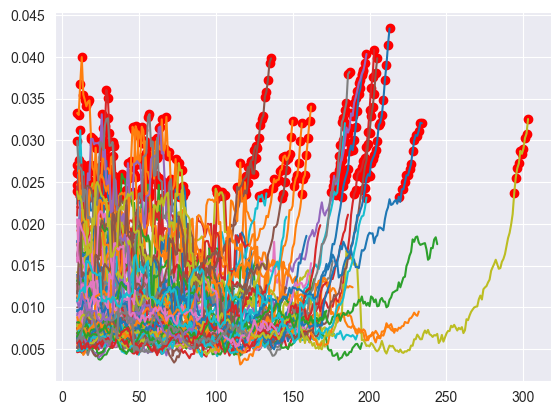

In [138]:
# Evaluate the model using the test data and the defined threshold and percentage
results = model_evaluation(test_data, model, THRESHOLD, 0.9)
y_true = results["y_true"]
y_pred = results["y_pred"]

En el gráfico que muestra la función se puede ver como, a medida que el error crece y supera un umbral, el ciclo es clasificado como una anomalía.

A continuación, se calcula y muestra la matriz de confusión del modelo. Como en detección de anomalías existe un número muy limitado de casos positivos o anómalos, la matriz se calcula en porcentaje para poder mostrar correctamente cuánto acierta y cuánto falla el modelo, ya que, si no, quedaría completamente desbalanceada la matriz.

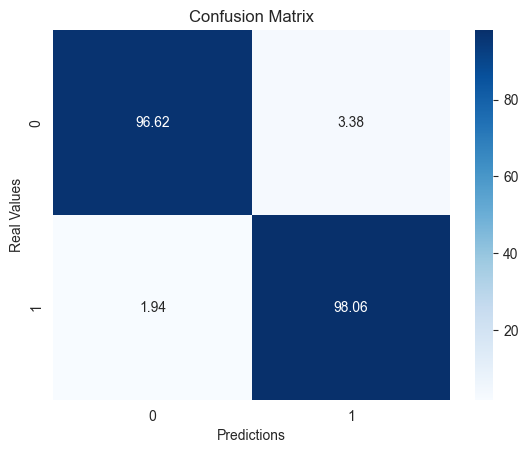

In [142]:
from sklearn.metrics import confusion_matrix
# Función para crear la matriz de confusión
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
    plt.figure()
    sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Blues", xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.xlabel("Predictions")
    plt.ylabel("Real Values")
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_true, y_pred, "Confusion Matrix")

Como se puede ver, el modelo es capaz de clasificar correctamente como anómalos el 98.06% de los ciclos que realmente representaban una anomalía y deja pasar únicamente un 1.94% de los casos que eran anómalos. Por otro lado, solamente un 3.38% de los ciclos normales son confundidos por anómalos. Aunque esta cifra es ligeramente mayor que la de falsos negativos, en un caso como este, en el que se quieren detectar fallos en un entorno crítico, es preferible que el número de falsos positivos sea mayor y la menor cantidad de fallos sean pasados por alto.

# 4. XAI

Una vez se ha probado el modelo, en este apartado se procede a aplicar y estudiar diferentes técnicas de explicabilidad. El estudio se realiza en tres partes mediante diferentes técnicas de XAI. Por un lado, se utilizan dos métodos de la librería SHAP. Se crean también explicaciones con la librería LIME y, finalmente, se muestra la técnica de integrated gradients.

## 4.1 SHAP

En primer lugar, se realiza un estudio mediante los valores SHapley Additive exPlanations o valores SHAP.

Basado en la teoría de juego, SHAP asigna valores de atribución que permiten caracterizar cómo variables individuales afectan a los valores predecidos por el LSTM. A diferencia de otros métodos, SHAP se puede utilizar tanto para crear explicaciones globales como a nivel de instancia. Esto lo convierte en un método muy interesante para modelos de detección de anomalías.

Para aplicar SHAP se pasan los datos a un formato 2D que la librería SHAP pueda utilizar. Para poder realizar predicciones con estos datos, se debe crear también una función de predicción que toma el array en 2D y lo vuelve a formatear de forma que el modelo pueda predecir en 3D. Después, se crea un Explainer de tipo Kernel, que es compatible con la arquitectura del modelo LSTM, con un subconjunto de instancias del entrenamiento. Finalmente, se selecciona un subconjunto de test para la explicación. El uso de subconjuntos es debido al alto coste computacional de la técnica en el cálculo de los valores SHAP.

In [7]:
import shap

background_data = results["sequences"][np.random.choice(results["sequences"].shape[0], 100, replace=False)]

nsamples, seq_len, nfeatures = background_data.shape
background_data_reshaped = background_data.reshape((nsamples, seq_len * nfeatures))

# Función para la predicción
def f(x_reshaped):
    # Reshape a 3D y predecir
    x_3d = x_reshaped.reshape((-1, seq_len, nfeatures))

    predictions = model.predict(x_3d, verbose=0)

    # Calcular MSE
    min_length = min(predictions.shape[1], seq_len)
    errors = np.power(x_3d[:, :min_length, :] - predictions[:, :min_length, :], 2)
    mse = np.mean(errors, axis=(1, 2))

    return mse

# Crear SHAP explainer
explainer = shap.KernelExplainer(f, background_data_reshaped)

# Seleccionar subconjunto de test para la explicación
test_data_subset = results["sequences"][np.random.choice(results["sequences"].shape[0], 100, replace=False)]

# Reshape a 2D
nsamples_test, seq_len_test, nfeatures_test = test_data_subset.shape
test_data_subset_reshaped = test_data_subset.reshape((nsamples_test, seq_len_test * nfeatures_test))

# Calcular valores SHAP
shap_values = explainer.shap_values(test_data_subset_reshaped)

100%|██████████| 100/100 [59:50<00:00, 35.90s/it]

SHAP values shape: (100, 240)


Una vez se han calculado los valores SHAP, se puede proceder con las dos técnicas de explicabilidad.

### 4.1.1 Summary plot

Este análisis clasifica las variables según su valor SHAP medio absoluto mostrando su influencia global en la predicción del MSE.

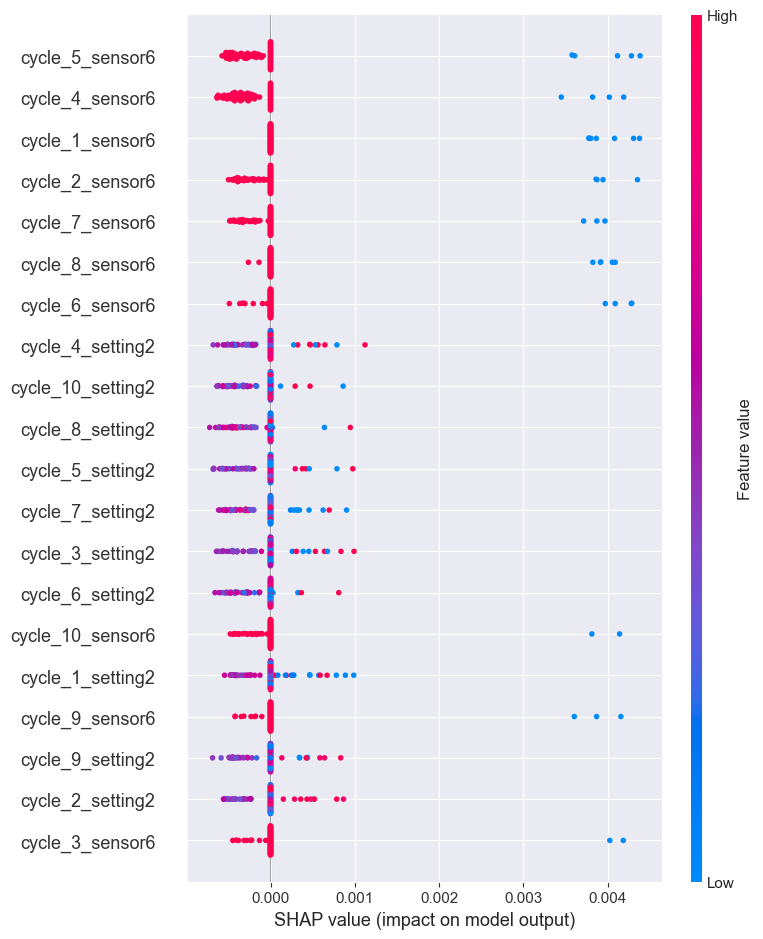

In [9]:
# Crear nombres para cada variable de medida por ciclo
flattened_feature_names = []
for i in range(seq_len):
    for feature_name in results["features"]:
        flattened_feature_names.append(f"cycle_{i+1}_{feature_name}")

# Generar SHAP summary plot
shap.summary_plot(shap_values, test_data_subset_reshaped, feature_names=flattened_feature_names, max_display=20)

Como se puede ver, especialmente el sensor 6 es gran responsable de las predicciones clasificadas como anomalías en el dataset.

### 4.1.2 Waterfall plot

El waterfall plot se realiza mediante la decomposición de la predicción a nivel de instancia. En él se muestra cómo cada variable afecta al valor de MSE en la predicción partiendo del valor MSE medio del modelo.

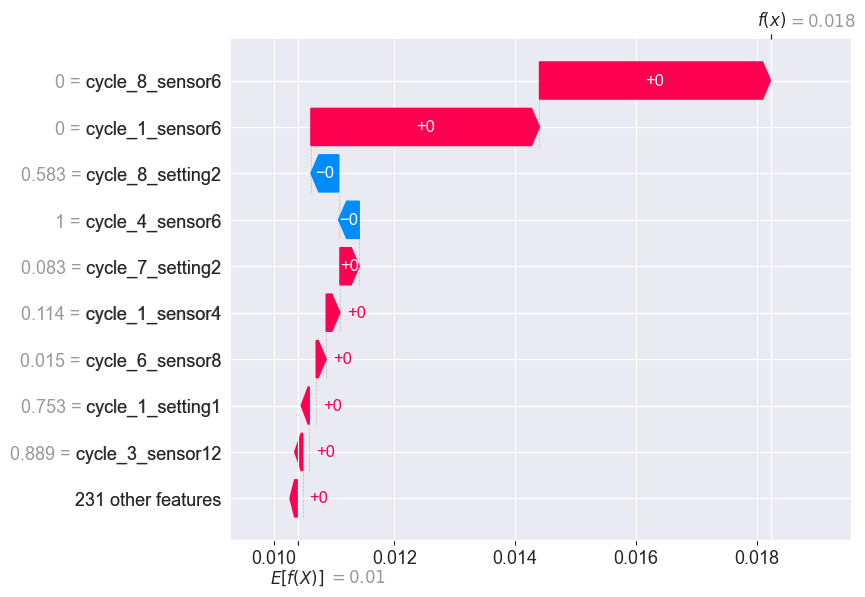

In [113]:
import random

# Elegir una instancia aleatoria para la explicación
random_instance_index = random.randint(0, nsamples_test - 1)

# Obtener los datos y los valores SHAP de la instancia
shap_values_instance = shap_values[random_instance_index]
instance_data_reshaped = test_data_subset_reshaped[random_instance_index]

# Crear un Explainer para el waterfall plot
# Tomar el valor base del modelo
base_value_scalar = explainer.expected_value

explanation_for_waterfall = shap.Explanation(
    values=shap_values_instance,
    base_values=base_value_scalar,
    data=instance_data_reshaped,
    feature_names=flattened_feature_names
)

# Create the waterfall plot
shap.waterfall_plot(explanation_for_waterfall, show=False)
plt.show()

Como se puede ver en el gráfico, una vez más, el sensor 6 es el gran responsable del aumento del valor del MSE aportando los dos mayores incrementos.

## 4.2 LIME

A continuación, se hace un estudio de explicabilidad local mediante LIME. LIME anazlia las anomalías de forma aislada aproximando el comportamiento del modelo LSTM de forma local ultilizando un modelo lineal. Tratando cada medida de los sensores en una ventana de tiempo fijada como una variable independiente, se analiza su impacto en la predicción.

En este contexto, LIME es particularmente útil para analizar las anomalías y entender los factores locales que disparan estas predicciones. Dada una instancia clasificada como anómala, LIME perturba ligeramente cada una de las variables y observa cómo afecta cada uno de los cambios a la salida del modelo.

Para poder ejecutar LIME, primero se debe crear una función de predicción y preparar los datos en un array numpy bidimensional que utiliza la librería. La función transforma primero los datos de vuelta al mismo formato que admite el modelo originalmente para poder realizar la predicción.

In [117]:
import lime.lime_tabular

# Función de predicción para utilizar en LIME
def predict_fn(x_reshaped):
    # Reshape para que el modelo pueda predecir
    seq_len = SEQUENCE_LENGTH
    nfeatures = len(results["features"])
    x_3d = x_reshaped.reshape((-1, seq_len, nfeatures))
    # Realizar la predicción
    predictions = model.predict(x_3d, verbose=0)
    # Calcular MSE
    min_length = min(predictions.shape[1], seq_len)
    errors = np.power(x_3d[:, :min_length, :] - predictions[:, :min_length, :], 2)
    mse = np.mean(errors, axis=(1, 2))

    return mse

# Convertir los datos a numpy array de 2D que LIME pueda utilizar
nsamples, seq_len, nfeatures = results["sequences"].shape
test_data_reshaped_for_lime = results["sequences"].reshape((nsamples, seq_len * nfeatures))

print("Shape of test_data_reshaped_for_lime:", test_data_reshaped_for_lime.shape)

Shape of test_data_reshaped_for_lime: (12196, 240)


Una vez los datos están preparados para la librería y se ha creado la función de predicción, se debe crear el Explainer. Se selecciona, además, uno de los ciclos clasificados como anómalos si los hay. Con el Explainer se crea la explicación.

In [173]:
# Crear el objeto explainer de LIME
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=test_data_reshaped_for_lime,
    mode='regression',
    feature_names=flattened_feature_names,
    random_state=1
)

# Seleccionar una instancia anómala si las hay
anomaly_indices = np.where(results["y_pred"] == 1)[0]
if len(anomaly_indices) > 0:
    instance_index_to_explain = np.random.choice(anomaly_indices)
    print(f"Se va a explicar la instancia anómala con índice: {instance_index_to_explain}")
else:
    instance_index_to_explain = np.random.randint(0, test_data_reshaped_for_lime.shape[0])
    print(f"No se ha clasificado ninguna anomalía. Se va a explicar una instancia aleatoria con el índice: {instance_index_to_explain}")

instance_to_explain = test_data_reshaped_for_lime[instance_index_to_explain]

# Generar la explicación para la instancia seleccionada
explanation = explainer_lime.explain_instance(
    data_row=instance_to_explain,
    predict_fn=predict_fn,
    num_features=10
)

Se va a explicar la instancia anómala con índice: 11009


Una vez se ha creado la explicación, la librería LIME permite visualizarla en un notebook de forma más comprensible. En ella se muestran tres columnas, una con el valor de MSE predecido que ha clasificado la instancia como anómala. Otra en la que se comparan las variables que han afectado positiva o negativamente a la predicción según su valor. Finalmente, en la tercera columna, se muestran las variables y su valor con color naranja si han afectado positivamente al MSE o azul si ha sido de forma negativa.

In [170]:
# Mostrar visualización
explanation.show_in_notebook(show_table=True, show_all=False)

## 4.3 Integrated Gradients

Finalmente, se hace uso de la técnica de Integrated Gradients. Este método atribuye el resultado de la predicción a sus características de entrada mediante el cálculo de la integral de los gradientes a lo largo del camino que va desde una entrada de referencia hasta la instancia analizada. Es una técnica especialmente diseñada para redes neuronales profundas, como en este caso el modelo LSTM, ya que soluciona problemas de saturación de gradientes y es fiel al funcionamiento interno del modelo.

El primer paso para aplicar esta técnica consiste en definir nuestra entrada de referencia. Se utiliza un tensor de ceros que representa la ausencia de características, respetando las dimensiones de entrada del modelo. A continuación, se escoge un subconjunto representativo de los datos de test, seleccionando de forma aleatoria tanto ciclos sanos (bajo MSE) como ciclos anómalos (alto MSE) para poder contrastar y explicar las decisiones del modelo en ambos tipos de escenarios.

In [128]:
# Definir el input de referencia
nfeatures = len(results["features"])
baseline_input = np.zeros((1, SEQUENCE_LENGTH, nfeatures), dtype=np.float32) # Use float32 as models often expect this dtype

print("Baseline input shape:", baseline_input.shape)

# Seleccionar un subconjunto de instancias anómalas y sanas
mse_values = results["mse"]
y_pred = results["y_pred"]

anomaly_indices = np.where(y_pred == 1)[0]
healthy_indices = np.where(y_pred == 0)[0]

num_instances_to_explain = 5

# Instancias anómalas
if len(anomaly_indices) > num_instances_to_explain:
    selected_anomaly_indices = np.random.choice(anomaly_indices, num_instances_to_explain, replace=False)
else:
    selected_anomaly_indices = anomaly_indices
print(f"Selected {len(selected_anomaly_indices)} anomaly instances.")

# Instancias sanas
if len(healthy_indices) > num_instances_to_explain:
    selected_healthy_indices = np.random.choice(healthy_indices, num_instances_to_explain, replace=False)
else:
    selected_healthy_indices = healthy_indices
print(f"Selected {len(selected_healthy_indices)} healthy instances.")

# Combinar y mezclar
selected_indices = np.concatenate([selected_anomaly_indices, selected_healthy_indices])
np.random.shuffle(selected_indices)

# Obtener las secuencias
selected_test_data_subset = results["sequences"][selected_indices]

print("Shape of selected test data subset:", selected_test_data_subset.shape)

# Predecir con las instancias seleccionadas
try:
    prediction_subset = model.predict(selected_test_data_subset, verbose=0)
    prediction_baseline = model.predict(baseline_input, verbose=0)
    print("\nModel successfully predicted on the selected subset and baseline input.")
    print("Prediction shape on subset:", prediction_subset.shape)
    print("Prediction shape on baseline:", prediction_baseline.shape)
except Exception as e:
    print(f"Error during model prediction verification: {e}")

Baseline input shape: (1, 10, 24)
Selected 5 anomaly instances.
Selected 5 healthy instances.
Shape of selected test data subset: (10, 10, 24)

Model successfully predicted on the selected subset and baseline input.
Prediction shape on subset: (10, 10, 24)
Prediction shape on baseline: (1, 10, 24)


Una vez definidas las instancias y el baseline, se procede a la implementación del cálculo. Para ello, se aprovecha la funcionalidad `GradientTape` de TensorFlow, que permite registrar las operaciones para el cálculo automático de gradientes del error respecto a las entradas. El algoritmo interpola gradualmente la entrada desde el baseline hasta el valor real de la instancia, calculando y promediando los gradientes en cada paso (50 pasos en este ejemplo) para obtener finalmente la atribución real de cada variable al MSE.

In [129]:
import tensorflow as tf

# Definir una funcion de gradiente con GradientTape de TensorFlow
def compute_gradients(model, inputs):
    with tf.GradientTape() as tape:
        tape.watch(inputs) # Watch the input tensor
        # Obtener predicciones
        predictions = model(inputs)

        # Calcular MSE
        min_length = min(predictions.shape[1], inputs.shape[1])
        errors = tf.pow(inputs[:, :min_length, :] - predictions[:, :min_length, :], 2)
        mse = tf.reduce_mean(errors, axis=[1, 2])

    # Calcular el gradiente del MSE
    return tape.gradient(mse, inputs)

# Función para calcular los gradientes integrados de una instancia
def integrated_gradients(model, instance, baseline, steps=50):
    """Calculates Integrated Gradients for a single instance."""
    # Usar tipo de dato correcto
    instance = tf.cast(instance, tf.float32)
    baseline = tf.cast(baseline, tf.float32)

    # Pasos de interpolación
    interpolated_inputs = [
        baseline + (step / steps) * (instance - baseline) for step in range(steps + 1)
    ]
    # Combinar en un tensor de tamaño (steps + 1, 1, SEQUENCE_LENGTH, nfeatures)
    interpolated_inputs = tf.stack(interpolated_inputs)

    # Reshape a (steps + 1, SEQUENCE_LENGTH, nfeatures) para mantener el formato del modelo
    interpolated_inputs = tf.squeeze(interpolated_inputs, axis=1)

    # Calcular los gradientes en cada paso
    gradients = compute_gradients(model, interpolated_inputs)

    # Media de gradientes en cada paso de interpolación
    avg_gradients = tf.reduce_mean(gradients, axis=0)

    # Cálculo de los gradientes integrados
    instance_squeezed = tf.squeeze(instance, axis=0)
    baseline_squeezed = tf.squeeze(baseline, axis=0)
    integrated_grad = (instance_squeezed - baseline_squeezed) * avg_gradients

    return integrated_grad.numpy()

# Calcular gradientes para las instancias seleccionadas
integrated_gradients_attributions = []

print(f"Calculating Integrated Gradients for {selected_test_data_subset.shape[0]} instances...")

for i, instance in enumerate(selected_test_data_subset):
    instance_reshaped = np.expand_dims(instance, axis=0)
    ig_attribution = integrated_gradients(model, instance_reshaped, baseline_input, steps=50)
    integrated_gradients_attributions.append(ig_attribution)

    # Progreso
    if (i + 1) % 1 == 0 or (i + 1) == selected_test_data_subset.shape[0]:
        print(f"Processed {i + 1}/{selected_test_data_subset.shape[0]} instances.")


# Convertir la lista a un único array
integrated_gradients_attributions = np.array(integrated_gradients_attributions)
print("\nShape of integrated_gradients_attributions:", integrated_gradients_attributions.shape)

# Guardar en results para poder guardar recuperar los resultados
results["integrated_gradients_attributions"] = integrated_gradients_attributions
results["selected_indices_for_ig"] = selected_indices

Calculating Integrated Gradients for 10 instances...
Processed 1/10 instances.
Processed 2/10 instances.
Processed 3/10 instances.
Processed 4/10 instances.
Processed 5/10 instances.
Processed 6/10 instances.
Processed 7/10 instances.
Processed 8/10 instances.
Processed 9/10 instances.
Processed 10/10 instances.

Shape of integrated_gradients_attributions: (10, 10, 24)


Con las puntuaciones de atribución ya calculadas para cada instante de la secuencia temporal, se procede a su visualización. La forma más intuitiva de representar estos datos tridimensionales es mediante mapas de calor o heatmaps.

En estos gráficos, el eje horizontal representa el paso de tiempo en la secuencia y el eje vertical muestra las diferentes características, es decir, los sensores. Los colores cálidos señalan características que incrementaron el MSE empujando al modelo a predecir una anomalía, mientras que los colores fríos indican que esa característica redujo el error.

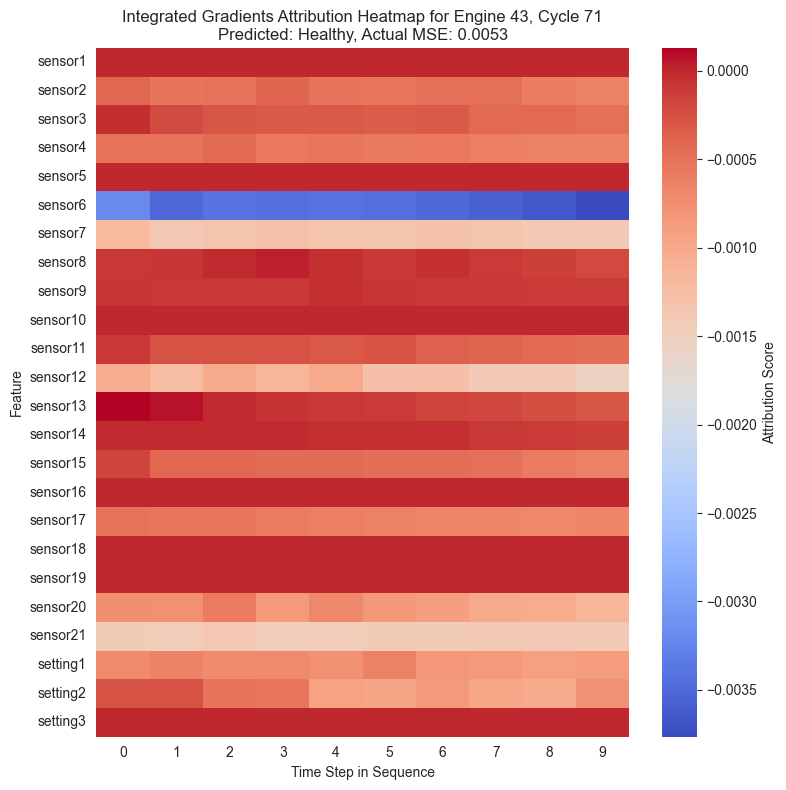

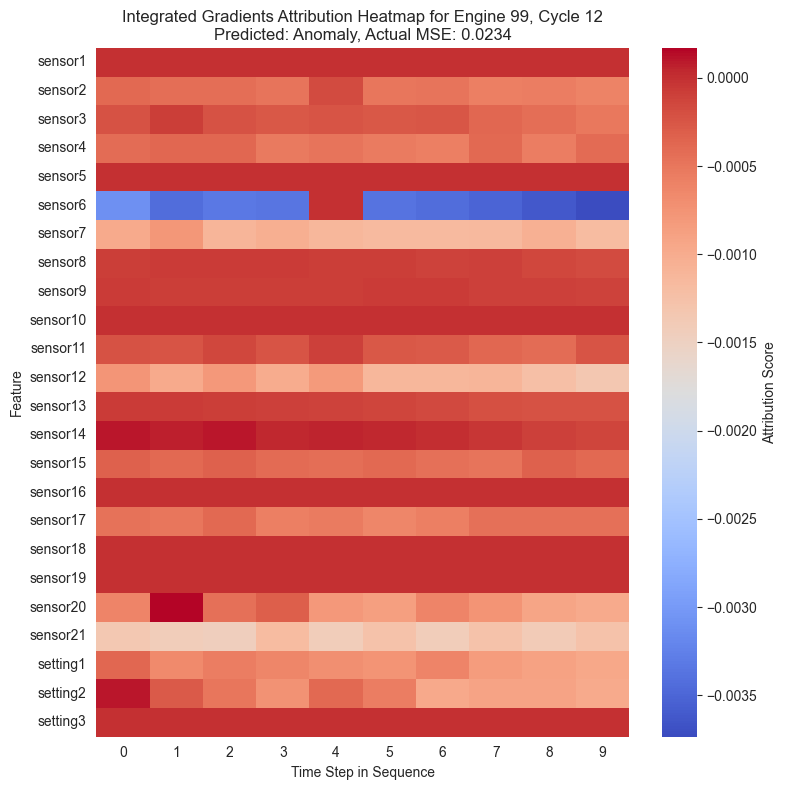

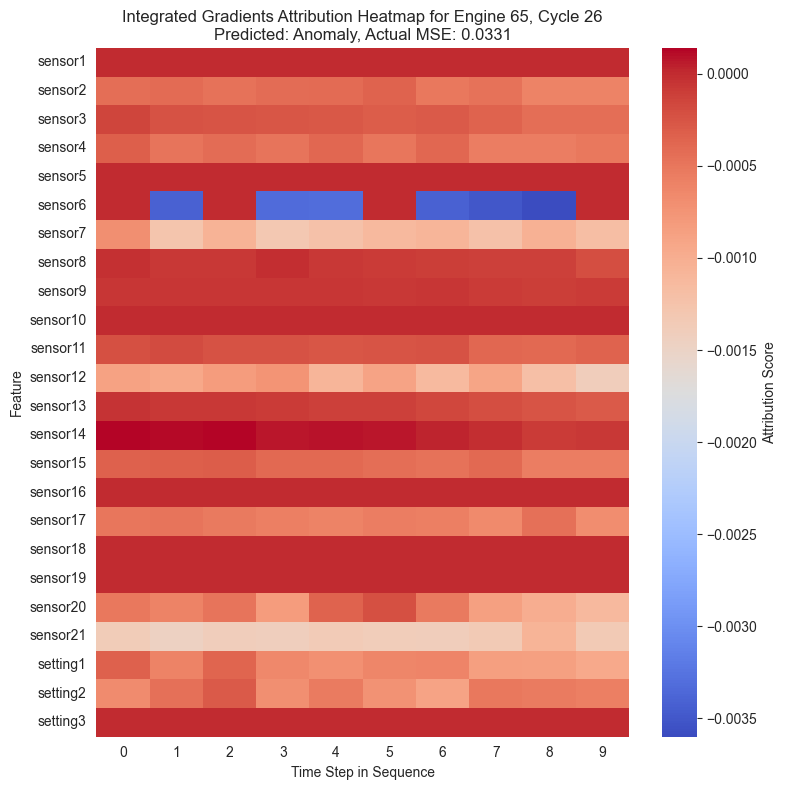

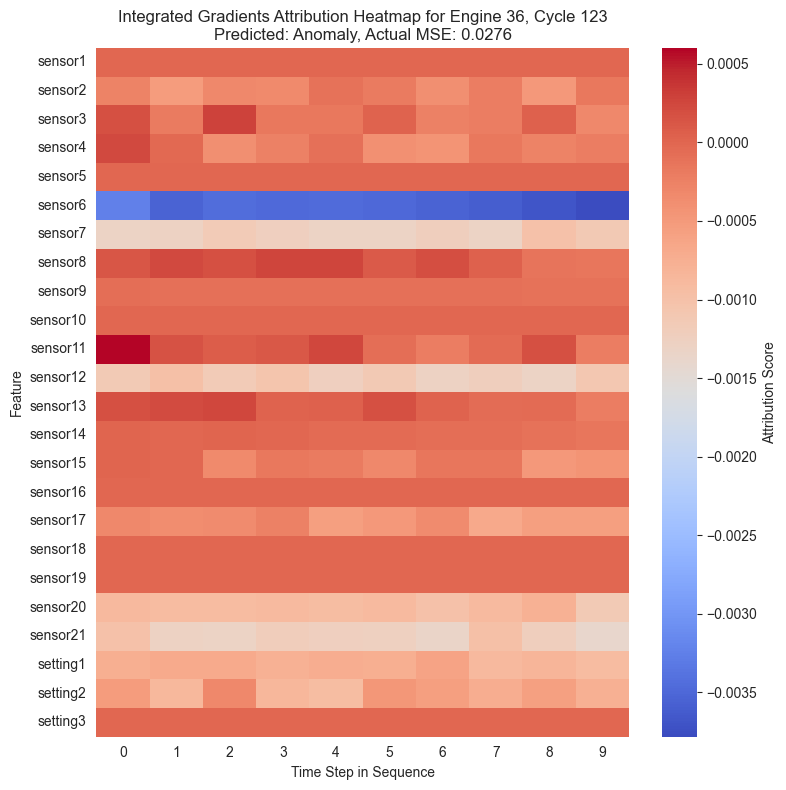

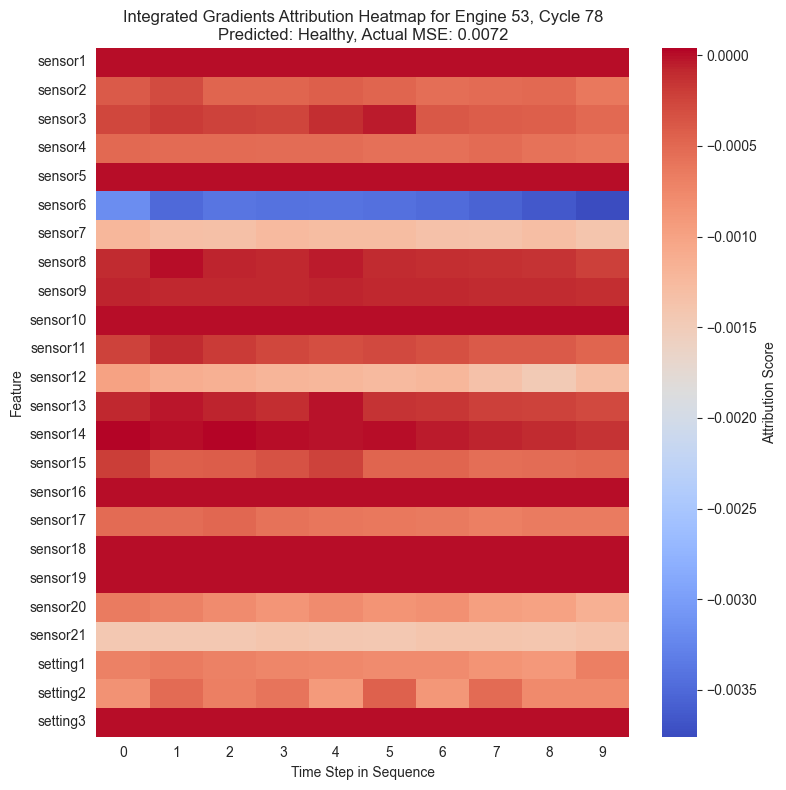

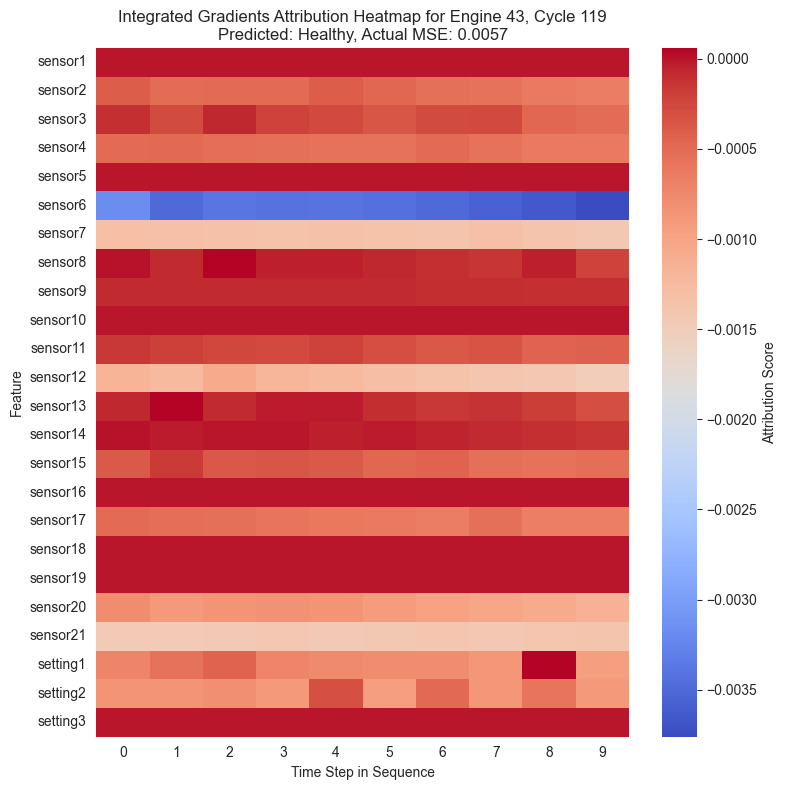

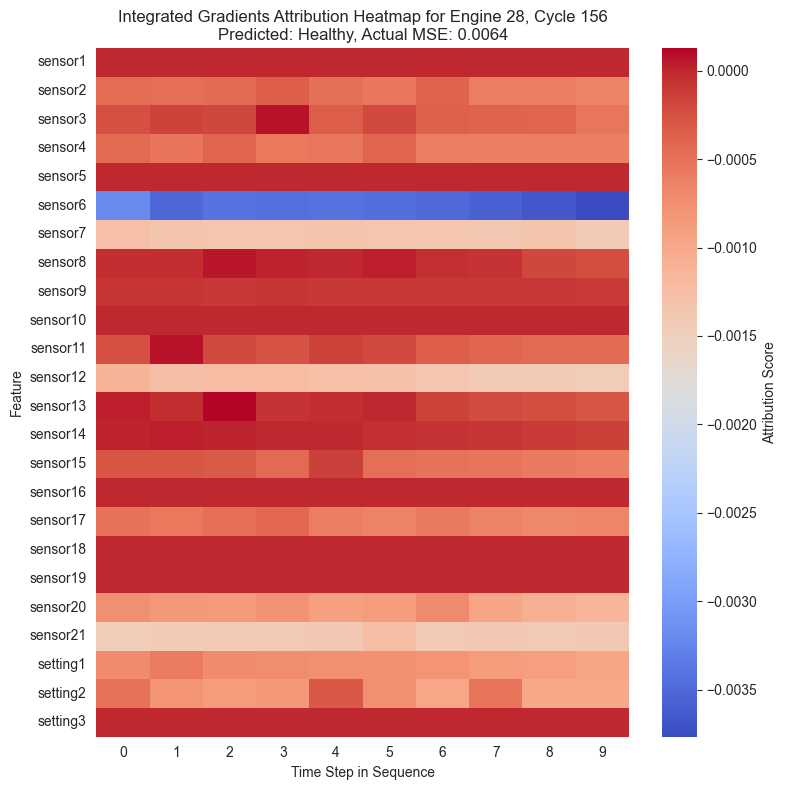

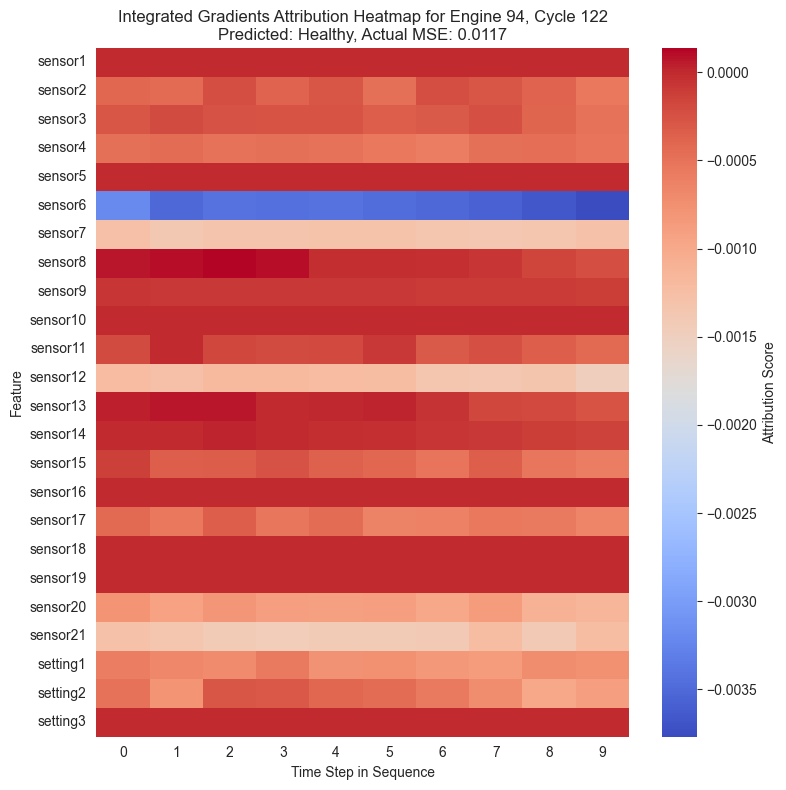

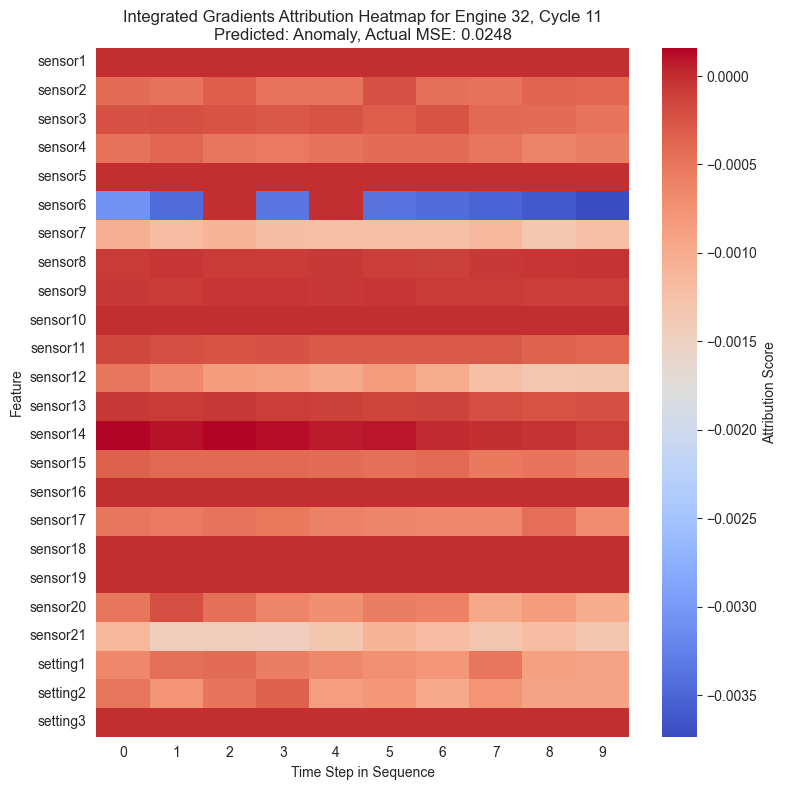

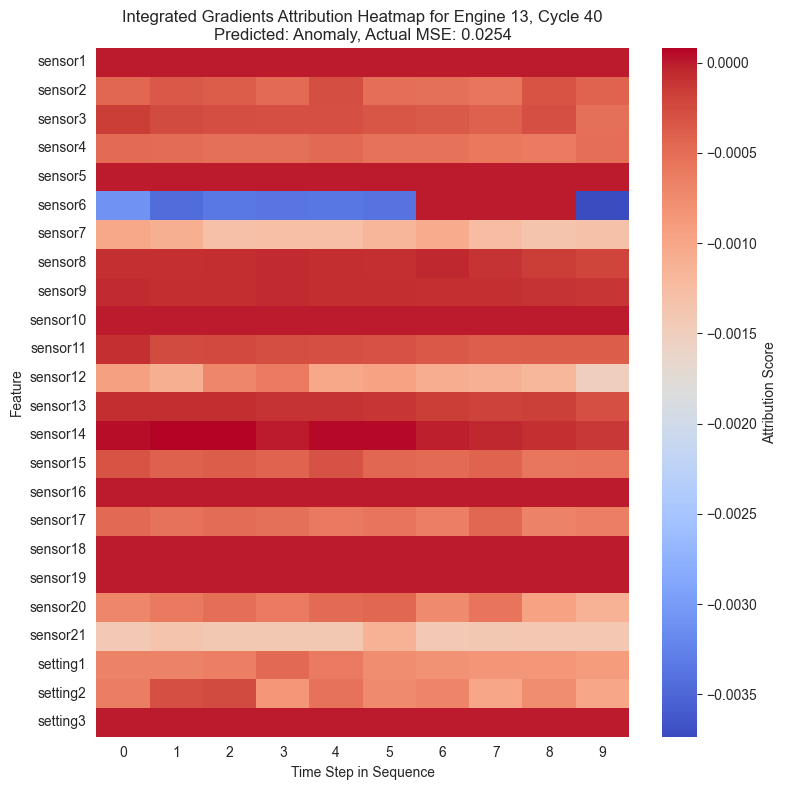

In [130]:
# Recuperar los datos utilizados
selected_indices_for_ig = results["selected_indices_for_ig"]
ig_attributions_subset = results["integrated_gradients_attributions"]

# Obtener los datos asociados necesarios
selected_y_pred = results["y_pred"][selected_indices_for_ig]
selected_mse = results["mse"][selected_indices_for_ig]
selected_engine_ids = results["engine_ids"][selected_indices_for_ig]
selected_cycles = results["cycles"][selected_indices_for_ig]

feature_names = results["features"]

# Crear un heatmap para cada instancia
for i in range(ig_attributions_subset.shape[0]):
    attribution_scores = ig_attributions_subset[i]
    instance_engine_id = selected_engine_ids[i]
    instance_cycle = selected_cycles[i]
    instance_predicted_status = "Anomaly" if selected_y_pred[i] == 1 else "Healthy"
    instance_actual_mse = selected_mse[i]

    # Ajustes de gráfico
    plt.figure(figsize=(8, 8))
    ax = sns.heatmap(attribution_scores.T, cmap="coolwarm", annot=False, cbar=True)
    cbar = ax.collections[0].colorbar
    cbar.set_label("Attribution Score")
    plt.xlabel("Time Step in Sequence")
    plt.ylabel("Feature")
    plt.yticks(np.arange(len(feature_names)) + 0.5, feature_names, rotation=0)
    plt.title(f"Integrated Gradients Attribution Heatmap for Engine {instance_engine_id}, Cycle {instance_cycle}\nPredicted: {instance_predicted_status}, Actual MSE: {instance_actual_mse:.4f}")
    plt.tight_layout()
    plt.show()

Al igual que se ha observado anteriormente, se puede ver cómo en la mayoría de casos el sensor 6 muestra una importancia alta en la clasificación de una instancia como anómala. Cuando una instancia ha sido maracada como anómala, el sensor 6 muestra valores especialmente altos en rojo mientras que en el resto está mayormente azul.